# The Overnight Puzzle: Decomposing Equity Returns

A well-documented oddity in US equities: nearly all of the equity risk premium accrues **overnight** (yesterday's close to today's open), while the **intraday** session (open to close) earns roughly nothing. This notebook replicates the finding on SPY, stress-tests it across sub-periods and other assets, and asks the question that actually matters — does it survive trading costs?

**Definitions**

- Overnight return = today's open ÷ yesterday's close − 1
- Intraday return = today's close ÷ today's open − 1

The two legs compound to the full daily return: $(1 + r_{on})(1 + r_{id}) = 1 + r_{daily}$.

**One trap handled up front:** dividends land in the overnight gap. Mixing an adjusted close with an unadjusted open would corrupt the decomposition, so all prices here are downloaded with `auto_adjust=True` — dividends and splits are folded into every field consistently.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import fetch_ohlc
from src.returns import decompose, summary_table, wealth_curve, ann_return, sharpe

spy = fetch_ohlc("SPY")
returns = decompose(spy)
print(f"{len(returns)} trading days, {returns.index[0].date()} to {returns.index[-1].date()}")
returns.tail()

8419 trading days, 1993-02-01 to 2026-07-14


,overnight,intraday,daily
Date,,,
2026-07-08,-0.006085,0.003014,-0.003089
2026-07-09,0.002616,0.005834,0.008465
2026-07-10,0.000452,0.003856,0.004310
2026-07-13,-0.003285,-0.004386,-0.007656
2026-07-14,0.002323,0.002064,0.004392


## Stage 1 — Replicate

Three wealth curves from the same price series: buy-and-hold, holding **only overnight** (buy every close, sell every open), and holding **only intraday** (buy every open, sell every close). No costs yet — this is the anomaly in its cleanest form.

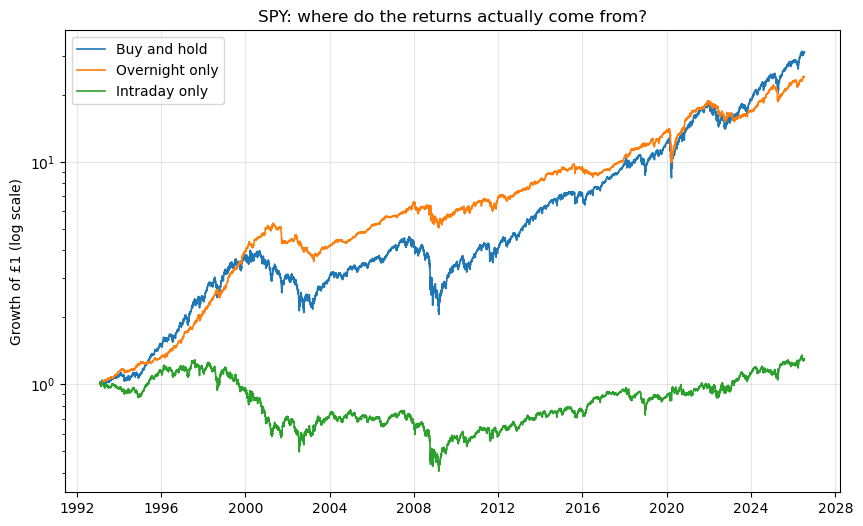

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
for col, label in [("daily", "Buy and hold"), ("overnight", "Overnight only"),
                   ("intraday", "Intraday only")]:
    ax.plot(wealth_curve(returns[col]), label=label, lw=1.2)
ax.set_yscale("log")
ax.set_ylabel("Growth of £1 (log scale)")
ax.set_title("SPY: where do the returns actually come from?")
ax.legend()
ax.grid(alpha=0.3);

In [3]:
summary_table(returns)

,ann_return_%,ann_vol_%,sharpe
overnight,9.99,10.60,0.95
intraday,0.78,15.21,0.13
daily,10.85,18.57,0.65


In [4]:
# Total growth of £1 in each leg over the whole sample
(1 + returns).prod().round(2)

overnight    24.08
intraday      1.30
daily        31.21
dtype: float64

The overnight leg earns essentially the entire equity premium at roughly **half the volatility** of buy-and-hold, so its Sharpe ratio is far higher. The intraday leg spends three decades going nowhere.

One data caveat worth checking before trusting this: if Yahoo ever prints a stale open (open set equal to the previous close), the overnight return shows up as exactly zero and the decomposition is distorted. How common is that?

In [5]:
zero_overnight = returns["overnight"].abs() < 1e-6
(100 * zero_overnight.groupby(returns.index.year // 10 * 10).mean()).round(2).rename("% of days with zero overnight return")

Date
1990    5.43
2000    1.03
2010    1.27
2020    0.24
Name: % of days with zero overnight return, dtype: float64

Around 5% of days in the 1990s look stale, falling to well under 2% afterwards — worth flagging, not enough to overturn the picture (a stale open shifts return *between* the legs on that day, and the effect is far larger than that).

## Stage 2 — Stress-test

Does the effect persist across sub-periods, or is it an artefact of one era? And does it exist outside SPY?

In [6]:
periods = {
    "1993-2009": (None, "2009-12-31"),
    "2010-2026": ("2010-01-01", None),
    "2020 crash (19 Feb - 30 Apr)": ("2020-02-19", "2020-04-30"),
    "2022": ("2022-01-01", "2022-12-31"),
}

def leg_summary(r):
    return {
        "overnight %/yr": 100 * ann_return(r["overnight"]),
        "overnight Sharpe": sharpe(r["overnight"]),
        "intraday %/yr": 100 * ann_return(r["intraday"]),
        "intraday Sharpe": sharpe(r["intraday"]),
        "days": len(r),
    }

pd.DataFrame({label: leg_summary(returns.loc[s:e]) for label, (s, e) in periods.items()}).T.round(2)

,overnight %/yr,overnight Sharpe,intraday %/yr,intraday Sharpe,days
1993-2009,11.26,1.09,-3.29,-0.11,4263.0
2010-2026,8.71,0.82,5.13,0.45,4156.0
2020 crash (19 Feb - 30 Apr),-59.58,-1.62,22.74,0.79,51.0
2022,-13.39,-0.98,-5.60,-0.19,251.0


The effect is strongest pre-2010 (intraday was outright *negative* for seventeen years) and weakens afterwards — intraday earns a respectable 5% a year from 2010. It also fails exactly when you would want protection: overnight was crushed in the 2020 crash (gap-downs happen overnight) and lost money in 2022. This is not a hedge; it is where the premium normally sits.

Same decomposition across assets — a second index, three large caps from different sectors, and gold:

In [7]:
tickers = ["SPY", "QQQ", "AAPL", "MSFT", "JPM", "GLD"]
pd.DataFrame({t: leg_summary(decompose(fetch_ohlc(t))) for t in tickers}).T.round(2)

,overnight %/yr,overnight Sharpe,intraday %/yr,intraday Sharpe,days
SPY,9.99,0.95,0.78,0.13,8419.0
QQQ,13.88,0.98,-2.63,-0.00,6877.0
AAPL,21.90,0.91,-0.03,0.17,8438.0
MSFT,10.61,0.67,6.47,0.37,8438.0
JPM,10.82,0.63,2.42,0.23,8438.0
GLD,10.65,0.85,-0.28,0.04,5444.0


It refuses to die anywhere: every asset earns more overnight than intraday, including gold — which suggests this is not purely an equity-risk-premium story. The gap is most extreme in QQQ and AAPL, and narrowest in MSFT and JPM.

## Stage 3 — Trade it honestly

The naive strategy is: buy every close, sell every open. That is **one round trip per day, ~252 a year**, so costs compound brutally: each 1 bp of round-trip cost knocks roughly 2.5 percentage points off the annual return.

In [8]:
overnight = returns["overnight"]
breakeven = overnight.mean() * 1e4  # round-trip bps that sets the mean net return to zero

costs = np.arange(0, 5.5, 0.5)
sweep = pd.DataFrame({
    "net %/yr": [100 * ann_return(overnight - c / 1e4) for c in costs],
    "net Sharpe": [sharpe(overnight - c / 1e4) for c in costs],
}, index=pd.Index(costs, name="round-trip cost (bps)")).round(2)

print(f"Breakeven round-trip cost: {breakeven:.2f} bps")
sweep

Breakeven round-trip cost: 4.00 bps


,net %/yr,net Sharpe
round-trip cost (bps),,
0.0,9.99,0.95
0.5,8.61,0.83
1.0,7.25,0.71
1.5,5.91,0.60
2.0,4.59,0.48
2.5,3.28,0.36
3.0,1.98,0.24
3.5,0.71,0.12
4.0,-0.55,0.00


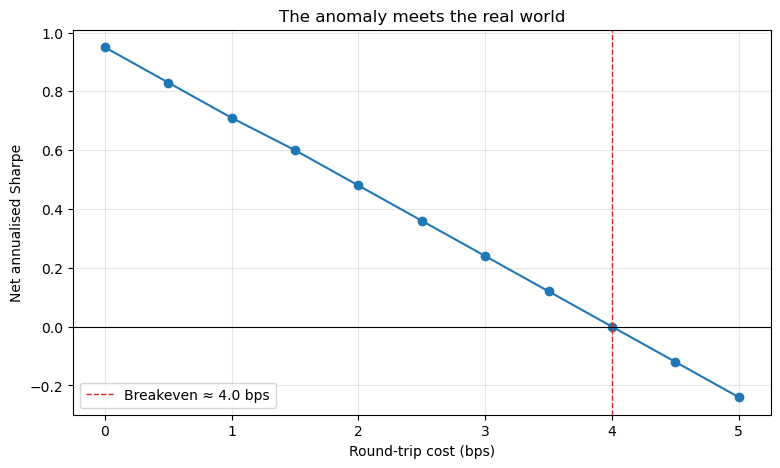

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep.index, sweep["net Sharpe"], marker="o")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(breakeven, color="tab:red", ls="--", lw=1,
           label=f"Breakeven ≈ {breakeven:.1f} bps")
ax.set_xlabel("Round-trip cost (bps)")
ax.set_ylabel("Net annualised Sharpe")
ax.set_title("The anomaly meets the real world")
ax.legend()
ax.grid(alpha=0.3);

**The strategy survives only if round-trip costs are under ~4 bps.** SPY is about the cheapest instrument on earth — the quoted spread is typically ~1 bp — but you cross it twice a day, plus commissions and (crucially) you systematically buy at the close and sell at the open, exactly when everyone running this trade would. Under ~2 bps the trade nominally clears; there is no realistic retail path to that, and at institutional cost levels the surviving edge is a fraction of the paper anomaly.

## Stage 4 — When is the overnight return biggest?

Two cheap conditionals. First: does tonight's overnight return depend on what the market did today?

In [10]:
prev_day = returns["daily"].shift(1)
bins = [-np.inf, -0.02, -0.01, 0, 0.01, 0.02, np.inf]
labels = ["< -2%", "-2% to -1%", "-1% to 0%", "0% to 1%", "1% to 2%", "> 2%"]
grouped = returns["overnight"].groupby(pd.cut(prev_day, bins=bins, labels=labels), observed=True)

pd.DataFrame({
    "mean overnight (bps)": (1e4 * grouped.mean()).round(2),
    "t-stat": (grouped.mean() / (grouped.std() / np.sqrt(grouped.count()))).round(2),
    "days": grouped.count(),
})

,mean overnight (bps),t-stat,days
daily,,,
< -2%,8.02,1.08,337
-2% to -1%,7.65,2.41,718
-1% to 0%,5.41,5.21,2810
0% to 1%,3.69,4.30,3379
1% to 2%,-0.17,-0.07,900
> 2%,-7.37,-0.97,274


A clean, almost monotone pattern: overnight returns are largest after down days (~8 bps) and turn *negative* after strong up days — consistent with a short-horizon reversal on top of the base effect.

Second: scheduled FOMC announcement days (dates from the Fed's website, in `reference/fomc_dates.csv`). The famous pre-FOMC drift (Lucca & Moench, 2015) says returns are unusually high in the 24 hours before the announcement:

In [11]:
fomc = pd.to_datetime(pd.read_csv("../reference/fomc_dates.csv")["date"])
on_fomc = returns.index.isin(fomc)
day_after = returns.index.isin(fomc + pd.offsets.BDay(1))

groups = {
    "FOMC announcement day": returns[on_fomc],
    "day after FOMC": returns[day_after & ~on_fomc],
    "all other days": returns[~on_fomc & ~day_after],
}
pd.DataFrame({label: {
    "mean overnight (bps)": round(1e4 * r["overnight"].mean(), 2),
    "mean intraday (bps)": round(1e4 * r["intraday"].mean(), 2),
    "days": len(r),
} for label, r in groups.items()}).T

,mean overnight (bps),mean intraday (bps),days
FOMC announcement day,13.38,11.17,259.0
day after FOMC,1.56,-3.83,257.0
all other days,3.78,0.58,7903.0


## Conclusions

1. **The anomaly is real in the data.** 1993–2026, SPY's overnight leg earned ~10% annualised (Sharpe ~0.95) against ~0.8% intraday (Sharpe ~0.13) — buy-and-hold's entire return, at half the volatility.
2. **It is robust but not invincible.** It holds in every asset tested (even gold), weakens after 2010, and the overnight leg takes the crashes — 2020 and 2022 were both painful.
3. **It is not implementable at realistic costs.** One round trip per day means the edge dies at ~4 bps round-trip cost; net of anything a real investor pays, the tradeable version earns roughly nothing. The anomaly is best read as a fact about *when* the equity premium accrues, not as a strategy.
4. **Conditioning helps at the margin** — overnight returns are biggest after down days — but not enough to change the implementability verdict.

*Method notes: all prices auto-adjusted (dividends land in the overnight gap); Sharpe ratios use a zero risk-free rate; annualised returns are geometric. See the repo README and `paper/` for the full write-up.*